In [179]:
from datasets import load_dataset
import pandas as pd

#Cargar dataset
dataset=load_dataset("alidi/cwru-dataset")
# Ver qué contiene
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['channel', 'signal', 'signal_length', 'speed', 'motor_load', 'label', 'key', 'sampling_frequency'],
        num_rows: 8
    })
    test: Dataset({
        features: ['channel', 'signal', 'signal_length', 'speed', 'motor_load', 'label', 'key', 'sampling_frequency'],
        num_rows: 60
    })
})


In [180]:
df_train=dataset["train"].to_pandas()
print(df_train.columns)
print(df_train.shape)

Index(['channel', 'signal', 'signal_length', 'speed', 'motor_load', 'label',
       'key', 'sampling_frequency'],
      dtype='str')
(8, 8)


In [181]:
df_test=dataset["test"].to_pandas()
print(df_test.columns)
print(df_test.shape)

Index(['channel', 'signal', 'signal_length', 'speed', 'motor_load', 'label',
       'key', 'sampling_frequency'],
      dtype='str')
(60, 8)


In [182]:
df_train.head(3)

,channel,signal,signal_length,speed,motor_load,label,key,sampling_frequency
0,FE,"[0.14566727272727273, 0.09779636363636364, 0.0...",243938,29.950000,0.0,normal,29.95;0.0;normal,12000.0
1,DE,"[0.05319692307692307, 0.08866153846153846, 0.0...",243938,29.950000,0.0,normal,29.95;0.0;normal,12000.0
2,FE,"[0.023216363636363632, 0.08115454545454545, 0....",483903,29.533333,1.0,normal,29.533333333333335;1.0;normal,12000.0


In [183]:
signal=df_train.loc[0]["signal"]
print(type(signal))
print(signal.shape)

<class 'numpy.ndarray'>
(243938,)


In [184]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   channel             8 non-null      str    
 1   signal              8 non-null      object 
 2   signal_length       8 non-null      int64  
 3   speed               8 non-null      float64
 4   motor_load          8 non-null      float64
 5   label               8 non-null      str    
 6   key                 8 non-null      str    
 7   sampling_frequency  8 non-null      float64
dtypes: float64(3), int64(1), object(1), str(3)
memory usage: 914.0+ bytes


In [185]:
numeric_columns=df_train.select_dtypes(include="number").columns.to_list()
object_columns=df_train.select_dtypes(include="object").columns.to_list()


print("TIPOS DE COLUMNAS")
print("--"*60)
print(f"columnas numericas: {numeric_columns}")
print("--"*60)
print(f"columnas tipo objeto: {object_columns}")

TIPOS DE COLUMNAS
------------------------------------------------------------------------------------------------------------------------
columnas numericas: ['signal_length', 'speed', 'motor_load', 'sampling_frequency']
------------------------------------------------------------------------------------------------------------------------
columnas tipo objeto: ['channel', 'signal', 'label', 'key']


C:\Users\CHOPPE\AppData\Local\Temp\ipykernel_5712\2309980094.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns=df_train.select_dtypes(include="object").columns.to_list()


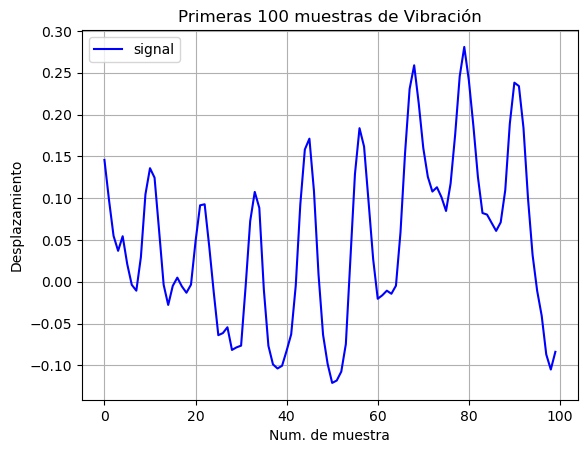

In [186]:
import matplotlib.pyplot as plt

plt.plot(signal[:100], color="blue", label="signal")
plt.title("Primeras 100 muestras de Vibración")
plt.grid(True, axis="both", which="both")
plt.xlabel("Num. de muestra")
plt.ylabel("Desplazamiento")
plt.legend(loc="upper left")

plt.show()


array([[<Axes: title={'center': 'signal_length'}>,
        <Axes: title={'center': 'speed'}>],
       [<Axes: title={'center': 'motor_load'}>,
        <Axes: title={'center': 'sampling_frequency'}>]], dtype=object)

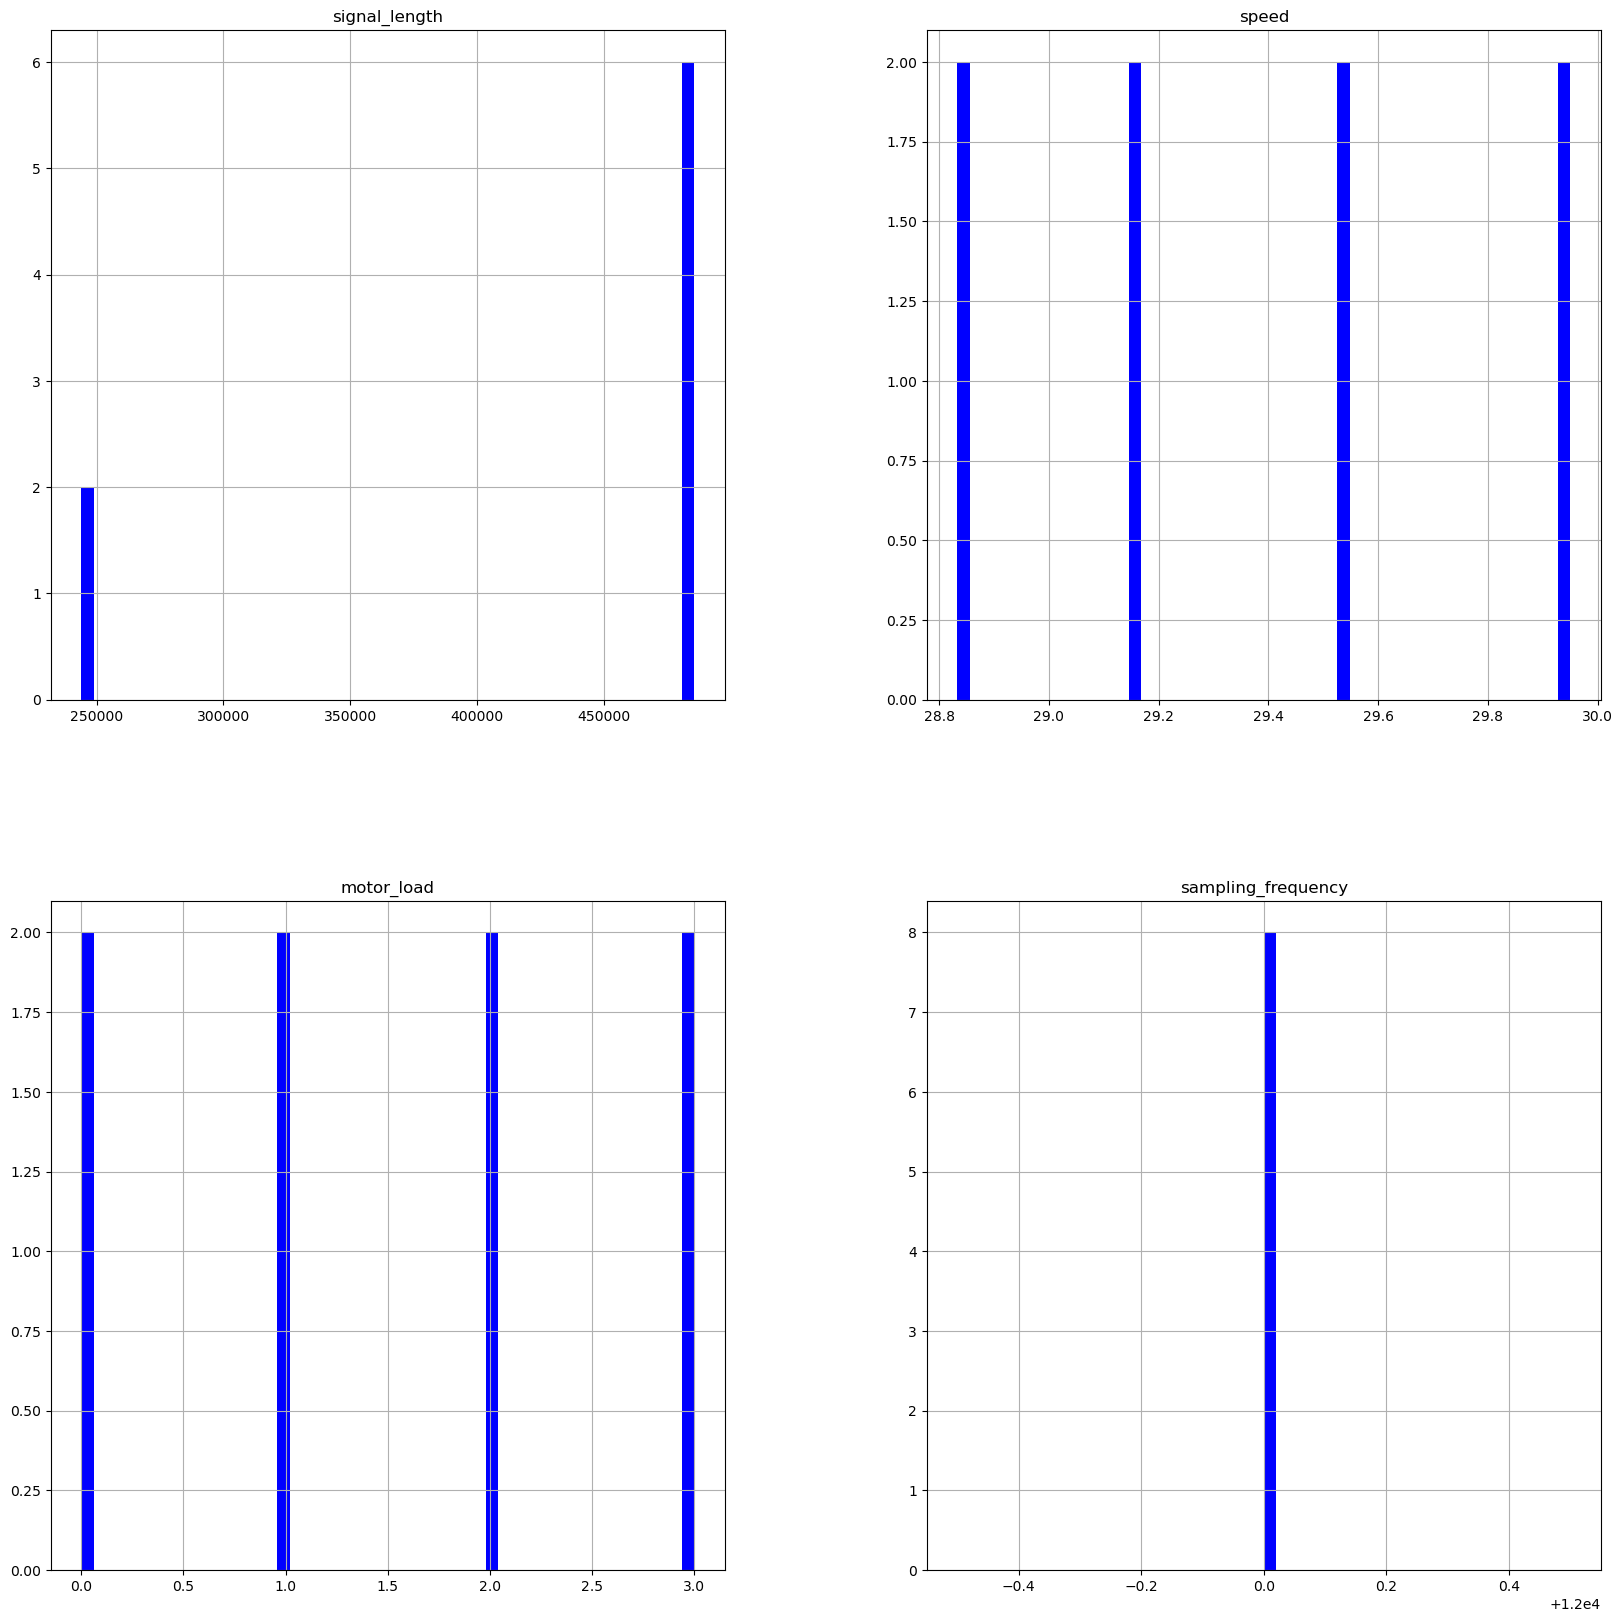

In [187]:
df_train.hist(color="blue", bins=50, figsize=(20,20))

In [188]:
# Ahora procedemos con un EDA de las variables categoricas: 
print(object_columns)

['channel', 'signal', 'label', 'key']


In [189]:
for i in object_columns:
    print("--"*60)
    print( f"Distribución variable: {i}")
    print(df_train[i].value_counts())
    print("--"*60)

------------------------------------------------------------------------------------------------------------------------
Distribución variable: channel
channel
FE    4
DE    4
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------------
Distribución variable: signal
signal
[0.14566727272727273, 0.09779636363636364, 0.05485636363636363, 0.03698181818181818, 0.05444545454545455, 0.02116181818181818, -0.003698181818181818, -0.010683636363636364, 0.02938, 0.10457636363636363, 0.13580545454545453, 0.12450545454545454, 0.06101999999999999, -0.003698181818181818, -0.027736363636363635, -0.004930909090909091, 0.004930909090909091, -0.005547272727272727, -0.013149090909090907, -0.0034927272727272728, 0.04828181818181818, 0.09142727272727272, 0.09265999999999999, 0.042529090909090905, -0.0127

In [190]:
df_train['channel'].value_counts()

channel
FE    4
DE    4
Name: count, dtype: int64

In [191]:
#Ahora como parte del preprocesamiento partimos la señal en varias señales pequeñas funcion windowing

import numpy as np

def create_windows(signal, window_size=1024, step=512):
    windows = []
    
    for i in range(0, len(signal) - window_size, step):
        window = signal[i:i + window_size]
        windows.append(window)
    
    return np.array(windows)

In [192]:
all_windows = []
labels = []

for _, row in df_train.iterrows(): #_, aqui viene un valor pero no lo ocupo indice. la fila completa como una especie de serie de pandas
    signal = np.array(row["signal"])
    
    windows = create_windows(signal) #Creo la lista de windows, cada lista con un tamaño de 1024 muestras
    
    all_windows.extend(windows)
    labels.extend([row["label"]] * len(windows))


In [193]:
X = np.array(all_windows)
y = np.array(labels)

print(X.shape)  # (n_ventanas, 1024)
print(y.shape)

(6624, 1024)
(6624,)


In [194]:
from scipy.stats import kurtosis, skew

def extract_features(window):
    return [
        np.mean(window),
        np.std(window),
        np.max(window),
        np.min(window),
        np.ptp(window),  # peak to peak
        kurtosis(window),
        skew(window),
        np.sqrt(np.mean(window**2)),  # RMS
        np.sum(window ** 2),
    ]

In [195]:
X_features = np.array([extract_features(w) for w in X])

print(X_features.shape)  # (n_samples, n_features)

(6624, 9)


In [198]:
X_features_columns=["media", "std", "max", "min", "ptp", "kurt", "skew", "RMS", "energy"]
print(X_features_columns)
df_features=pd.DataFrame(X_features, columns=X_features_columns)
df_features["label"]=y
df_features.head(5)

['media', 'std', 'max', 'min', 'ptp', 'kurt', 'skew', 'RMS', 'energy']


,media,std,max,min,ptp,kurt,skew,RMS,energy,label
0,0.026946,0.076094,0.280856,-0.196825,0.477682,-0.317613,0.215483,0.080724,6.672826,normal
1,0.026618,0.069609,0.225589,-0.161898,0.387487,-0.571799,0.164007,0.074524,5.687176,normal
2,0.026746,0.076953,0.237300,-0.188402,0.425702,-0.532995,0.087088,0.081468,6.796347,normal
3,0.027173,0.079305,0.264625,-0.188402,0.453027,-0.372884,0.186328,0.083831,7.196305,normal
4,0.027635,0.078804,0.264625,-0.186553,0.451178,-0.372701,0.148841,0.083509,7.141105,normal


array([[<Axes: title={'center': 'media'}>,
        <Axes: title={'center': 'std'}>, <Axes: title={'center': 'max'}>],
       [<Axes: title={'center': 'min'}>, <Axes: title={'center': 'ptp'}>,
        <Axes: title={'center': 'kurt'}>],
       [<Axes: title={'center': 'skew'}>,
        <Axes: title={'center': 'RMS'}>,
        <Axes: title={'center': 'energy'}>]], dtype=object)

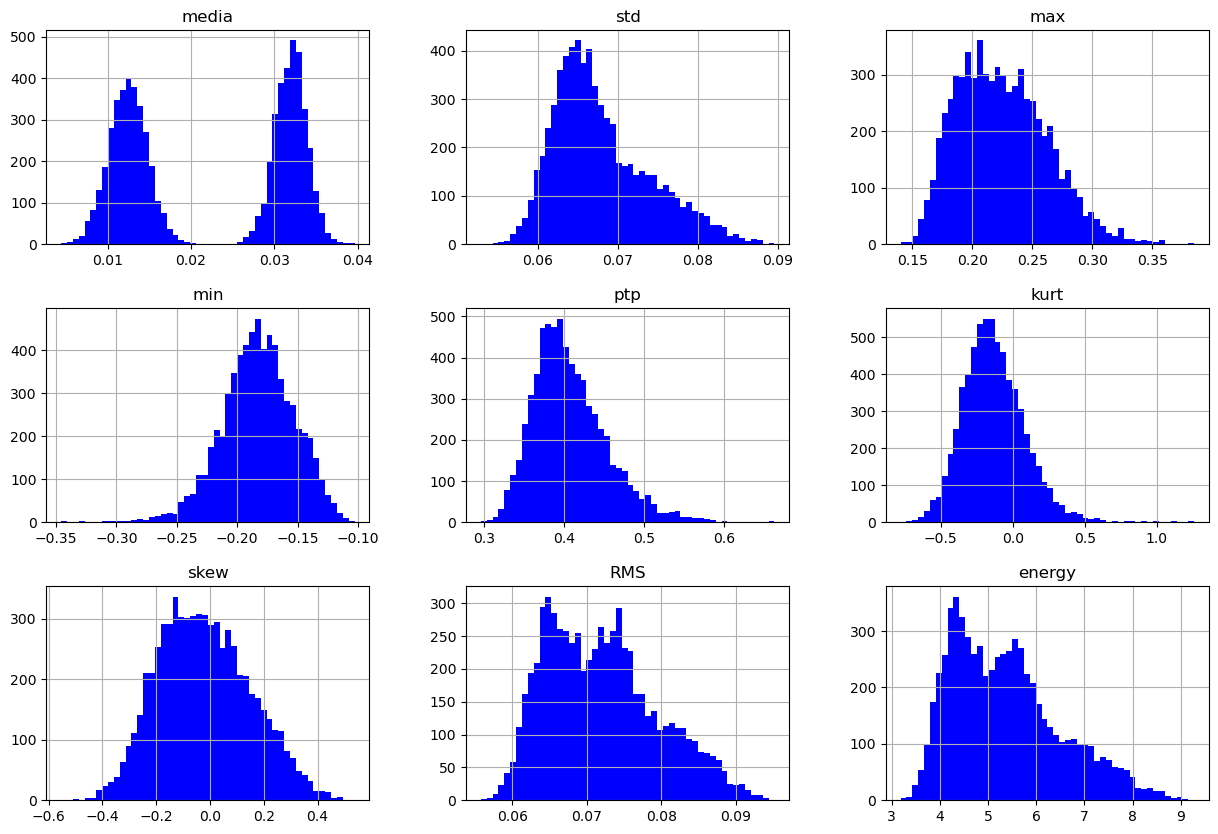

In [199]:
#Ahora procedemos a realizar un analisis exploratorio de los datos 
df_features.hist(bins=50, color="blue", figsize=(15,10))

In [200]:
X=df_features.drop(columns="label")


In [201]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val=train_test_split(X,y, test_size=0.2, random_state=42)

print(f"shape de training dataset:{X_train.shape}")
print(f"shape de val dataset:{X_val.shape}")

shape de training dataset:(5299, 9)
shape de val dataset:(1325, 9)


In [203]:
#Procedemos a generar un escalado de datos antes de inyectar estos datos en un autoencoder
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_std=scaler.fit_transform(X_train)
X_val_std=scaler.transform(X_val)

In [204]:
#Ahora procedemos con la definicion de un modelo de autoencoding capaz de poder reconstruir los datos de entrada 
#Es importante validar la reconstruccion con datos de validación 

In [205]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
input_dim=X_train.shape[1]
intermedio=6
bottleneck=2

autoencoder=Sequential([
    Dense(bottleneck, activation="relu", input_shape=(input_dim,)),
    Dense(input_dim, activation="linear")
   
])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

c:\Users\CHOPPE\Documents\CEROSA 2024\anaconda\envs\rag-env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 2)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 9)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47 (188.00 B)

 Trainable params: 47 (188.00 B)

 Non-trainable params: 0 (0.00 B)

In [206]:
from pathlib import Path, os

ruta_actual=Path.cwd()
#Creando carpeta modelo
Path("Vibrations_best_autoencoding_model").mkdir(exist_ok=True)
ruta_relativa_archivo=os.path.join("Vibrations_best_autoencoding_model", "best_model.keras")
ruta_modelo_autoencoding=os.path.join(ruta_actual, ruta_relativa_archivo)

print(ruta_modelo_autoencoding[-40:])

best_autoencoding_model\best_model.keras


In [207]:
from tensorflow.keras.callbacks import Callback
from keras.callbacks import ModelCheckpoint

callback=ModelCheckpoint(filepath=ruta_modelo_autoencoding, monitor="val_loss", verbose=True, save_best_only=True)

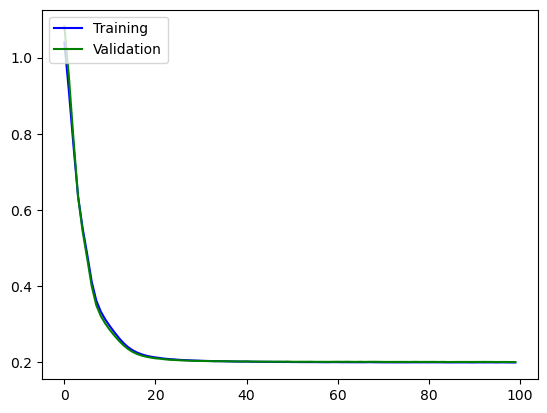

In [208]:
from time import time, sleep
from IPython.display import clear_output
max_iter=100
val_losses=[]
tr_losses=[]

for i in range (max_iter):
    autoencoder.fit(X_train_std, X_train_std, validation_data=(X_val_std, X_val_std), epochs=1,
                    verbose=True, callbacks=callback)
    loss_tr=autoencoder.evaluate(X_train_std, X_train_std, verbose=0)
    loss_val=autoencoder.evaluate(X_val_std, X_val_std, verbose=0)

    tr_losses.append(loss_tr)
    val_losses.append(loss_val)

    clear_output()
    plt.plot(tr_losses, color="blue", label="Training")
    plt.plot(val_losses, color="green", label="Validation")
    plt.legend(loc="upper left")
    plt.show()
    sleep(0.1)

In [209]:
#Ok mi modelo esta generalizando de manera correcta la reconstrucción de la data ahora creamos cargamos el modelo y probamos con los datos de entrenamiento 
from tensorflow.keras.models import load_model

model_autoencoder=load_model(ruta_modelo_autoencoding)

transformador de señales a features

In [210]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import kurtosis, skew


class SignalFeaturesTransf(BaseEstimator, TransformerMixin):
    def __init__(self, signal_col="signal", label_col=None, window_size=1024, step=512):
        self.signal_col = signal_col
        self.label_col = label_col
        self.window_size = window_size
        self.step = step
        self.feature_names_ = None

    def fit(self, X, y=None):
        return self

    def _create_windows(self, signal):
        windows = []
        for i in range(0, len(signal) - self.window_size + 1, self.step):
            windows.append(signal[i:i + self.window_size])
        return windows

    def _extract_features(self, window):
        window = np.asarray(window, dtype=float)

        rms = np.sqrt(np.mean(window ** 2))
        std = np.std(window)
        peak = np.max(np.abs(window))
        ptp = np.ptp(window)

        

        return {
            "mean": np.mean(window),
            "std": std,
            "max": np.max(window),
            "min": np.min(window),
            "ptp": ptp,
            "kurtosis": kurtosis(window, fisher=True, bias=False),
            "skewness": skew(window, bias=False),
            "rms": rms,
            "energy": np.sum(window ** 2),
        }

    def transform(self, X):
        X = X.copy()

        all_feature_rows = []
        metadata_rows = []

        for idx, row in X.iterrows():
            signal = np.asarray(row[self.signal_col], dtype=float)
            windows = self._create_windows(signal)

            for window_id, window in enumerate(windows):
                feats = self._extract_features(window)
                all_feature_rows.append(feats)

                meta = {
                    "original_index": idx,
                    "window_id": window_id,
                }

                if self.label_col is not None and self.label_col in row.index:
                    meta["label"] = row[self.label_col]

                metadata_rows.append(meta)

        features_df = pd.DataFrame(all_feature_rows)
        self.feature_names_ = features_df.columns.tolist()
        self.last_metadata_ = pd.DataFrame(metadata_rows)

        return features_df

In [211]:
from sklearn.pipeline import Pipeline

preprocessor=Pipeline([
    ("signal_features", SignalFeaturesTransf(signal_col="signal", label_col="label", window_size=1024, step=512)),
    ("scaler", StandardScaler().set_output(transform="pandas"))
])

In [227]:
X_test=dataset["test"].to_pandas()
X_test.head()

,channel,signal,signal_length,speed,motor_load,label,key,sampling_frequency
0,DE,"[1.6381794, -3.084302, -0.9228492, 3.0810468, ...",121351,29.533333,1.0,BSF,1772;1.0;B028_1__3006,12000.0
1,DE,"[-0.02663936127744511, 0.02647692614770459, 0....",121846,29.166667,2.0,BPFI,1750;2.0;IR014_2__171,12000.0
2,DE,"[0.005522794411177645, -0.10379604790419161, -...",122136,29.533333,1.0,BSF,1772;1.0;B014_1__186,12000.0
3,DE,"[0.1462368862275449, -0.08440491017964072, 0.0...",122136,29.533333,1.0,BPFO,1772;1.0;OR014@6_1__198,12000.0
4,DE,"[-0.0027613972055888225, -0.09632403193612774,...",122571,29.950000,0.0,BSF,1797;0.0;B007_0__118,12000.0


In [213]:
X_test.shape

(60, 8)

In [225]:
# 2. Fit-transform en train
X_train_prepared=preprocessor.fit_transform(df_train)
X_train_prepared.head(5)
print(X_train_prepared.shape)

#Metadatos para ubicar el label
train_meta=preprocessor.named_steps["signal_features"].last_metadata_.copy()
y_train= train_meta["label"].values
#print(y_train_windowed)

# 3. Dejar solo normales para entrenar AE
X_train_normal = X_train_prepared[y_train== "normal"]

# 4. Transform en test
X_test_prepared=preprocessor.transform(X_test)
test_meta=preprocessor.named_steps["signal_features"].last_metadata_.copy()
y_test=test_meta["label"].values


(6624, 9)


In [226]:
print(y_test)

<ArrowStringArray>
[ 'BSF',  'BSF',  'BSF',  'BSF',  'BSF',  'BSF',  'BSF',  'BSF',  'BSF',
  'BSF',
 ...
 'BPFI', 'BPFI', 'BPFI', 'BPFI', 'BPFI', 'BPFI', 'BPFI', 'BPFI', 'BPFI',
 'BPFI']
Length: 14193, dtype: str


In [215]:
#Entrenar autoencoder con datos normales 
# 5. Entrenar autoencoder
X_train_normal_np = X_train_normal.to_numpy()
model_autoencoder.fit(X_train_normal_np, X_train_normal_np, epochs=30, batch_size=64, verbose=1)

# 6. Reconstrucción test
X_test_np = X_test_prepared.to_numpy()
X_test_rec = autoencoder.predict(X_test_np, verbose=0)

# 7. MSE por ventana
mse_test = np.mean((X_test_np - X_test_rec) ** 2, axis=1)

# 8. Resultados
results_test = test_meta.copy()
results_test["mse"] = mse_test

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1989 
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1990
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1990
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1989
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1989
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1990
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1989
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1989
Epoch 9/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1989
Epoch 10/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1989
Epoch 11/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1989
Epoch 12/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1989
Epoch 13/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1989  
Epoch 14/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1989
Epoch 15/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step -

In [218]:
mse_test.shape

(14193,)

In [ ]:
df_test_prepared=pd.DataFrame(X_test_prepared)
df_test_prepared.head(5)
df_test_prepared["mse"]=mse_test
df_test_prepared["label"]=y_test
df_test_prepared.head(5)
df

,mean,std,max,min,ptp,kurtosis,skewness,rms,energy,mse,label
0,1.403741,322.308391,164.456368,-202.277098,263.526052,0.757024,0.288776,260.572835,3678.632436,1.092763e+06,BSF
1,1.907479,315.403387,164.456368,-202.277098,263.526052,1.806190,0.394182,254.993754,3528.107594,1.001507e+06,BSF
2,2.003982,317.779216,186.540573,-229.907704,299.216685,2.744675,0.310087,256.920538,3579.737668,1.025035e+06,BSF
3,2.211535,331.190375,186.540573,-229.907704,299.216685,2.973987,0.283157,267.787409,3877.939144,1.211490e+06,BSF
4,2.745718,350.482521,179.062901,-230.151982,293.347324,2.531892,0.325295,283.426569,4328.008660,1.524776e+06,BSF


In [ ]:
sns.boxplot(
    x=X_std["Engine Condition"],
    y=X_std["log1p(mse)"]
)

plt.title("MSE por clase (log)")
plt.show()